# Lab 7: Planning and Learning Integration

**MSDS 684 — Reinforcement Learning · Regis University**

**Author:** Morgan Cooper  
**Reading:** Sutton & Barto (2018), *Reinforcement Learning: An Introduction*, Chapter 8

---

## Objective

Implement Dyna-Q on Gymnasium's **Taxi-v3** to study how integrating a learned model with direct RL changes sample efficiency, then extend the agent to handle a non-stationary environment (Dyna-Q+) and a focused planning order (prioritized sweeping).

## What this notebook delivers

1. **Direct RL** baseline — pure Q-learning on Taxi-v3 (NumPy Q-table).
2. **Model Learning** — deterministic tabular model stored as `model[(s,a)] = (r, s')` in a Python dict.
3. **Planning** — *n* simulated Q-updates per real env step using sampled `(s,a)` from the model.
4. Sample-efficiency comparison: pure Q-learning (n=0) vs. Dyna-Q with **n ∈ {5, 10, 50}**.
5. **Dyna-Q+** with the `κ√τ` exploration bonus on a wrapper that changes the env after 1000 steps.
6. **Prioritized sweeping** with a `heapq`-backed priority queue keyed on TD-error magnitude.
7. Final synthesis: when models help, when they hurt, and what model error costs.

## Mapping to the four report sections

| Notebook part | Feeds into report section |
|---|---|
| Part 1–2 (concept + env) | Section 1: Project Overview |
| Part 3–9 (implementation, experiments, figures) | Section 2: Deliverables |
| Part 10 (debugging notes inline) | Section 3: AI Use Reflection |
| Part 11 (synthesis bullets) | Section 4: Speaker Notes |


---

## Part 1 — Setup and Imports

**Goal:** establish a reproducible environment for every experiment in the notebook.

**Steps:**

- Import `numpy`, `matplotlib`, `gymnasium`, `heapq`, `random`, `collections.defaultdict`, `dataclasses`.
- Set a master RNG seed and note that each experiment will use a list of seeds (≥ 10, ideally 30) for averaging.
- Configure matplotlib defaults (figure size, font size, grid).
- Create a `figures/` directory if it does not already exist — every plot saved here will be embedded in the PDF report.
- Capture library versions in a short markdown line so the notebook is self-documenting (Gymnasium has API drift between versions; record what was used).


In [22]:
import os
import random

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import gymnasium as gym

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

os.makedirs("figures", exist_ok=True)

# Gymnasium API has drifted between versions — record what was used.
print(f"numpy      {np.__version__}")
print(f"gymnasium  {gym.__version__}")
print(f"matplotlib {matplotlib.__version__}")


numpy      2.4.3
gymnasium  1.2.3
matplotlib 3.10.8


---

## Part 2 — Environment: Taxi-v3

**Goal:** describe the MDP precisely so Section 1 of the report has the required environment block.

**Steps:**

- Instantiate `gymnasium.make('Taxi-v3')` and confirm the API (`reset() -> (obs, info)`, `step() -> (obs, reward, terminated, truncated, info)`).
- Record the spec:
  - **State space:** 500 discrete states (taxi row × col × passenger location × destination).
  - **Action space:** 6 discrete actions — south, north, east, west, pickup, dropoff.
  - **Rewards:** −1 per step, +20 successful dropoff, −10 illegal pickup/dropoff.
  - **Termination:** successful dropoff; episodes also truncate after a step cap.
- Run a single random-policy episode just to verify the API contract; do **not** include this output in the final PDF.
- Note Taxi's properties relevant to Dyna-Q: small, discrete, deterministic transitions and rewards → a tabular dict model is exact and cheap.


In [23]:
env = gym.make("Taxi-v3")
env.action_space.seed(SEED)

n_states = env.observation_space.n
n_actions = env.action_space.n
print(f"States: {n_states}, Actions: {n_actions}")

# Random-policy smoke test to confirm the Gymnasium 5-tuple step API.
obs, info = env.reset(seed=SEED)
total_reward, steps = 0.0, 0
terminated = truncated = False
while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += float(reward)
    steps += 1

print(f"Random episode: {steps} steps, total reward = {total_reward}")
env.close()


States: 500, Actions: 6
Random episode: 200 steps, total reward = -911.0


---

## Part 3 — Direct RL Baseline (Q-learning, n = 0)

**Goal:** establish a model-free baseline that Dyna-Q must beat on sample efficiency.

**Steps:**

- Initialize `Q = np.zeros((n_states, n_actions))`.
- Implement `epsilon_greedy(Q, s, epsilon)` — break ties randomly.
- Train loop:
  - For each episode, step until `terminated or truncated`.
  - Apply Q-learning update: `Q[s,a] += alpha * (r + gamma * max(Q[s']) - Q[s,a])`.
  - Track per-episode return and per-real-step cumulative reward (Dyna-Q comparisons are plotted vs. real env steps, not episodes).
- Hyperparameters to record: `alpha`, `gamma`, `epsilon` (and any decay), episode cap, total real steps, number of seeds.
- Run across multiple seeds and store mean ± 95% CI of returns and cumulative reward.

Mean return over last 100 episodes: -12.58


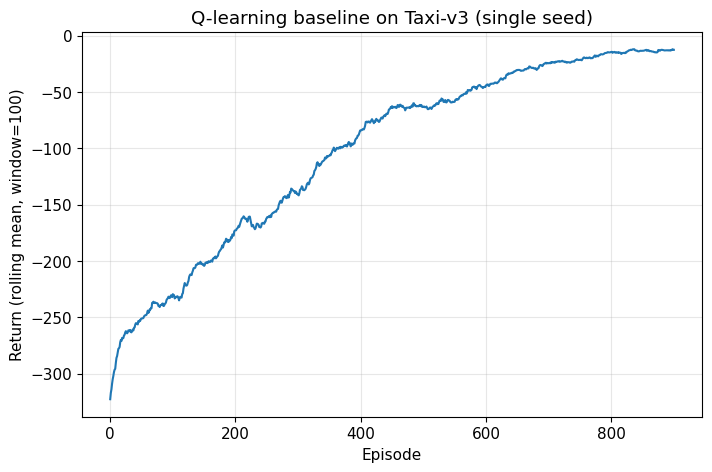

In [24]:
ALPHA = 0.1
GAMMA = 0.99
EPSILON = 0.1
NUM_EPISODES = 1000


def epsilon_greedy(Q, s, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(Q.shape[1]))
    best = np.flatnonzero(Q[s] == Q[s].max())
    return int(rng.choice(best))


def q_learning(env, num_episodes, alpha, gamma, epsilon, seed):
    rng = np.random.default_rng(seed)
    env.action_space.seed(seed)
    Q = np.zeros((n_states, n_actions))
    returns = np.zeros(num_episodes)

    s, _ = env.reset(seed=seed)
    for ep in range(num_episodes):
        if ep > 0:
            s, _ = env.reset()
        ep_return = 0.0
        terminated = truncated = False
        while not (terminated or truncated):
            a = epsilon_greedy(Q, s, epsilon, rng)
            s_next, r, terminated, truncated, _ = env.step(a)
            r = float(r)
            Q[s, a] += alpha * (r + gamma * Q[s_next].max() - Q[s, a])
            s = s_next
            ep_return += r
        returns[ep] = ep_return

    return Q, returns


env = gym.make("Taxi-v3")
Q_baseline, returns_baseline = q_learning(env, NUM_EPISODES, ALPHA, GAMMA, EPSILON, seed=SEED)
env.close()

print(f"Mean return over last 100 episodes: {returns_baseline[-100:].mean():.2f}")

window = 100
smoothed = np.convolve(returns_baseline, np.ones(window) / window, mode="valid")
plt.figure()
plt.plot(smoothed)
plt.xlabel("Episode")
plt.ylabel(f"Return (rolling mean, window={window})")
plt.title("Q-learning baseline on Taxi-v3 (single seed)")
plt.show()


---

## Part 4 — Dyna-Q: Three Processes in One Loop

**Goal:** implement the three integrated components from the lab brief.

**Steps:**

1. **Direct RL** — same Q-learning update as Part 3, applied to *real* `(s, a, r, s')` transitions.
2. **Model Learning** — after every real `env.step()`, write `model[(s, a)] = (r, s')`. Deterministic Taxi means each key has a single ground-truth target.
3. **Planning** — for `n` planning iterations per real step:
   - Sample `(s, a)` uniformly from `model.keys()`.
   - Look up `(r, s') = model[(s, a)]`.
   - Apply the same Q-learning update on this *simulated* experience.

**Implementation notes:**

- Keep `model` as a plain `dict` so `random.choice(list(model.keys()))` is straightforward; cache the key list and refresh only when new keys are added if profiling shows it matters.
- Wrap the agent in a class (e.g. `DynaQAgent`) so Dyna-Q+ and prioritized sweeping in later parts can subclass / share code.
- Verify with `n = 0` reproduces the Part 3 baseline exactly given the same seed.

Dyna-Q n=0  last-100 mean return: -12.58
Q-table matches Part 3 baseline:  True
Dyna-Q n=10 last-100 mean return: 2.09
Model size after training: 2384 unique (s, a) pairs


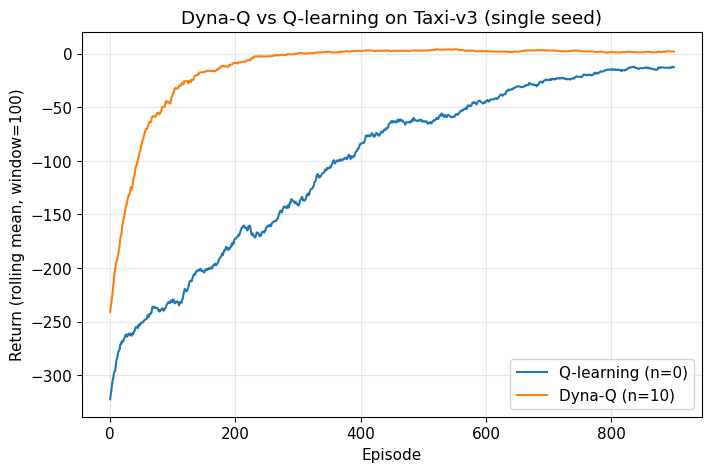

In [25]:
class DynaQAgent:
    def __init__(self, n_states, n_actions, alpha, gamma, epsilon, n_planning, seed):
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.n_planning = n_planning
        self.rng = np.random.default_rng(seed)
        self.Q = np.zeros((n_states, n_actions))
        self.model = {}

    def select_action(self, s):
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.n_actions))
        best = np.flatnonzero(self.Q[s] == self.Q[s].max())
        return int(self.rng.choice(best))

    def update(self, s, a, r, s_next):
        # Direct RL on the real transition.
        self.Q[s, a] += self.alpha * (r + self.gamma * self.Q[s_next].max() - self.Q[s, a])
        # Model learning: store the observed deterministic transition.
        self.model[(s, a)] = (r, s_next)
        # Planning: n simulated Q-updates from previously seen (s, a) pairs.
        if self.n_planning > 0:
            keys = list(self.model.keys())
            for _ in range(self.n_planning):
                sk, ak = keys[int(self.rng.integers(len(keys)))]
                rk, sk_next = self.model[(sk, ak)]
                self.Q[sk, ak] += self.alpha * (rk + self.gamma * self.Q[sk_next].max() - self.Q[sk, ak])


def train_dyna(env, agent, num_episodes, seed):
    returns = np.zeros(num_episodes)
    env.action_space.seed(seed)
    s, _ = env.reset(seed=seed)
    for ep in range(num_episodes):
        if ep > 0:
            s, _ = env.reset()
        ep_return = 0.0
        terminated = truncated = False
        while not (terminated or truncated):
            a = agent.select_action(s)
            s_next, r, terminated, truncated, _ = env.step(a)
            r = float(r)
            agent.update(s, a, r, s_next)
            s = s_next
            ep_return += r
        returns[ep] = ep_return
    return returns


# Sanity check: with n=0 the agent should reproduce the Part 3 baseline exactly.
env = gym.make("Taxi-v3")
agent_n0 = DynaQAgent(n_states, n_actions, ALPHA, GAMMA, EPSILON, n_planning=0, seed=SEED)
returns_n0 = train_dyna(env, agent_n0, NUM_EPISODES, seed=SEED)
env.close()

print(f"Dyna-Q n=0  last-100 mean return: {returns_n0[-100:].mean():.2f}")
print(f"Q-table matches Part 3 baseline:  {np.allclose(agent_n0.Q, Q_baseline)}")

# Confirm planning actually helps by running n=10.
env = gym.make("Taxi-v3")
agent_n10 = DynaQAgent(n_states, n_actions, ALPHA, GAMMA, EPSILON, n_planning=10, seed=SEED)
returns_n10 = train_dyna(env, agent_n10, NUM_EPISODES, seed=SEED)
env.close()

print(f"Dyna-Q n=10 last-100 mean return: {returns_n10[-100:].mean():.2f}")
print(f"Model size after training: {len(agent_n10.model)} unique (s, a) pairs")

# Quick comparison plot to eyeball the planning advantage.
window = 100
plt.figure()
for label, returns in [("Q-learning (n=0)", returns_n0), ("Dyna-Q (n=10)", returns_n10)]:
    smoothed = np.convolve(returns, np.ones(window) / window, mode="valid")
    plt.plot(smoothed, label=label)
plt.xlabel("Episode")
plt.ylabel(f"Return (rolling mean, window={window})")
plt.title("Dyna-Q vs Q-learning on Taxi-v3 (single seed)")
plt.legend()
plt.show()


---

## Part 5 — Sample-Efficiency Experiment (n ∈ {0, 5, 10, 50})

**Goal:** produce the headline comparison the lab brief calls for.

**Steps:**

- Fix `alpha`, `gamma`, `epsilon` across all four configurations so the only changing variable is `n`.
- For each `n` in `{0, 5, 10, 50}` and each seed, run training and log:
  - cumulative reward as a function of **real** env steps,
  - per-episode return,
  - real env steps to first reach an "optimal" performance threshold (define the threshold explicitly — e.g. mean return over last 100 episodes ≥ X).
- Aggregate across seeds → mean and 95% CI.
- Save raw arrays (e.g. `.npz`) so figures can be rebuilt without retraining.

In [26]:
N_PLANNING_VALUES = [0, 5, 10, 50]
N_SEEDS = 10               # bump to 30 for the final submission run
MAX_STEPS = 20_000         # real env steps per run
THRESHOLD = 0.0            # rolling-mean episode return >= 0 counts as "learned"
ROLLING_WINDOW = 100       # window for the rolling mean


def train_fixed_steps(env, agent, max_steps, seed):
    """Run agent for max_steps real env steps. Returns:
      - cum_reward: shape (max_steps,) running sum of rewards
      - episode_returns: 1D array of completed-episode returns
      - episode_end_steps: 1D array, real-step index at which each episode ended
    """
    cum_reward = np.zeros(max_steps)
    episode_returns = []
    episode_end_steps = []
    env.action_space.seed(seed)
    s, _ = env.reset(seed=seed)
    cum = 0.0
    ep_return = 0.0
    for step in range(max_steps):
        a = agent.select_action(s)
        s_next, r, terminated, truncated, _ = env.step(a)
        r = float(r)
        agent.update(s, a, r, s_next)
        cum += r
        ep_return += r
        cum_reward[step] = cum
        if terminated or truncated:
            episode_returns.append(ep_return)
            episode_end_steps.append(step + 1)
            ep_return = 0.0
            s, _ = env.reset()
        else:
            s = s_next
    return cum_reward, np.array(episode_returns), np.array(episode_end_steps)


def threshold_metrics(episode_returns, episode_end_steps, threshold, window):
    """Returns (episode_idx, real_step_idx) at which rolling mean first crosses
    threshold, or (-1, -1) if it never does."""
    if len(episode_returns) < window:
        return -1, -1
    rolling = np.convolve(episode_returns, np.ones(window) / window, mode="valid")
    crossed = np.where(rolling >= threshold)[0]
    if len(crossed) == 0:
        return -1, -1
    ep_idx = int(crossed[0]) + window - 1
    return ep_idx, int(episode_end_steps[ep_idx])


results = {n: {"cum_reward": [], "episodes_to_threshold": [], "steps_to_threshold": []}
           for n in N_PLANNING_VALUES}

for n in N_PLANNING_VALUES:
    for i in range(N_SEEDS):
        seed = SEED + i + 1
        env = gym.make("Taxi-v3")
        agent = DynaQAgent(n_states, n_actions, ALPHA, GAMMA, EPSILON, n_planning=n, seed=seed)
        cum, eps, ep_steps = train_fixed_steps(env, agent, MAX_STEPS, seed=seed)
        env.close()
        ep_thr, step_thr = threshold_metrics(eps, ep_steps, THRESHOLD, ROLLING_WINDOW)
        results[n]["cum_reward"].append(cum)
        results[n]["episodes_to_threshold"].append(ep_thr)
        results[n]["steps_to_threshold"].append(step_thr)
    cum_stack = np.stack(results[n]["cum_reward"])
    ep_thr_arr = np.array(results[n]["episodes_to_threshold"])
    n_solved = int((ep_thr_arr >= 0).sum())
    median_ep = int(np.median(ep_thr_arr[ep_thr_arr >= 0])) if n_solved > 0 else None
    print(f"n={n:>2}: final cum {cum_stack[:, -1].mean():+.0f} ± {cum_stack[:, -1].std():.0f} "
          f"| solved {n_solved}/{N_SEEDS} | median ep-to-threshold: {median_ep}")

# Cache results so Part 6 can rebuild figures without retraining.
save_kwargs = {}
for n in N_PLANNING_VALUES:
    save_kwargs[f"cum_n{n}"] = np.stack(results[n]["cum_reward"])
    save_kwargs[f"ep_thr_n{n}"] = np.array(results[n]["episodes_to_threshold"])
    save_kwargs[f"step_thr_n{n}"] = np.array(results[n]["steps_to_threshold"])
np.savez("results_part5.npz", **save_kwargs)
print("Saved results_part5.npz")


n= 0: final cum -33684 ± 203 | solved 0/10 | median ep-to-threshold: None
n= 5: final cum -29789 ± 584 | solved 0/10 | median ep-to-threshold: None
n=10: final cum -26527 ± 1541 | solved 2/10 | median ep-to-threshold: 373
n=50: final cum -16247 ± 1505 | solved 10/10 | median ep-to-threshold: 215
Saved results_part5.npz


---

## Part 6 — Visualizations for the Static Environment

**Goal:** generate the three figures the brief explicitly asks for.

**Plots to save to `figures/`:**

1. **Cumulative reward over real time steps** — one curve per `n`, with shaded 95% CI band.
2. **Episodes until optimal performance** — bar or box plot across `n` values, showing distribution over seeds.
3. **Sample efficiency** — real env interactions needed to reach the threshold, one bar per `n`.

**Caption discipline:**

- Captions must be **interpretive**, not descriptive. State *what* the figure shows AND *why* it matters (cite S&B Ch. 8 where relevant).
- Each figure goes into the PDF report; do not include console output dumps.

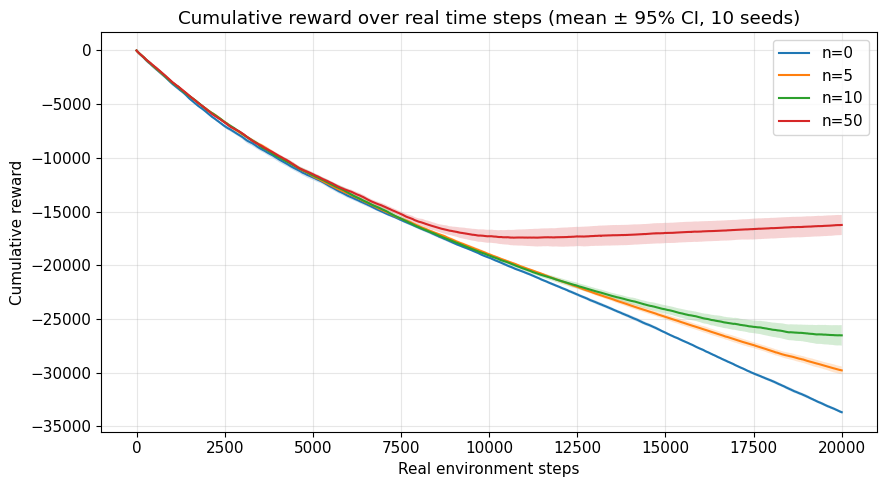

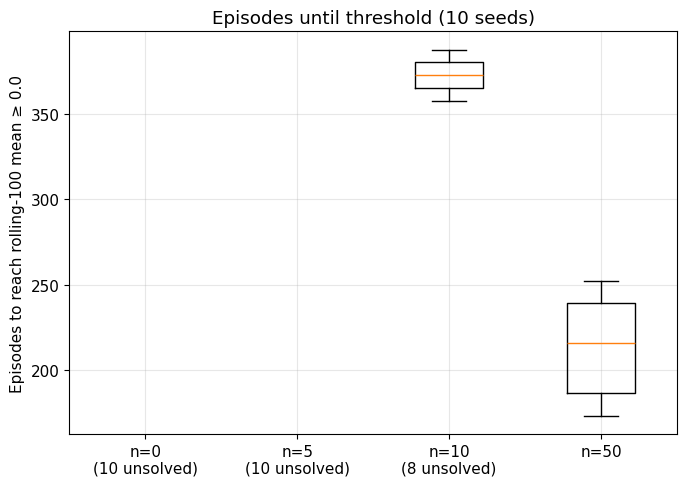

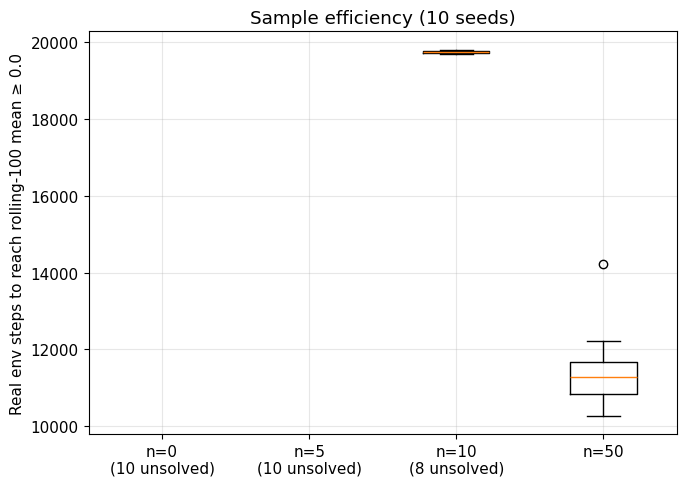

Saved figures: learning_curves.png, episodes_until_threshold.png, sample_efficiency.png


In [27]:
# Reload from disk so this cell is independent of Part 5's kernel state.
data = np.load("results_part5.npz")
ci_factor = 1.96
steps_axis = np.arange(MAX_STEPS)


# ---------- Figure 1: cumulative reward over real env steps ----------
plt.figure(figsize=(9, 5))
for n in N_PLANNING_VALUES:
    cum = data[f"cum_n{n}"]
    mean = cum.mean(axis=0)
    ci = ci_factor * cum.std(axis=0) / np.sqrt(cum.shape[0])
    plt.plot(steps_axis, mean, label=f"n={n}")
    plt.fill_between(steps_axis, mean - ci, mean + ci, alpha=0.2)
plt.xlabel("Real environment steps")
plt.ylabel("Cumulative reward")
plt.title(f"Cumulative reward over real time steps (mean ± 95% CI, {N_SEEDS} seeds)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/learning_curves.png", dpi=150)
plt.show()


# ---------- Figure 2: episodes until rolling mean >= threshold ----------
plt.figure(figsize=(7, 5))
boxes, xlabels = [], []
for n in N_PLANNING_VALUES:
    ep_thr = data[f"ep_thr_n{n}"]
    valid = ep_thr[ep_thr >= 0]
    failed = len(ep_thr) - len(valid)
    boxes.append(valid if len(valid) else np.array([np.nan]))
    xlabels.append(f"n={n}\n({failed} unsolved)" if failed else f"n={n}")
plt.boxplot(boxes)
plt.xticks(range(1, len(xlabels) + 1), xlabels)
plt.ylabel(f"Episodes to reach rolling-{ROLLING_WINDOW} mean ≥ {THRESHOLD}")
plt.title(f"Episodes until threshold ({N_SEEDS} seeds)")
plt.tight_layout()
plt.savefig("figures/episodes_until_threshold.png", dpi=150)
plt.show()


# ---------- Figure 3: real env steps until threshold ----------
plt.figure(figsize=(7, 5))
boxes, xlabels = [], []
for n in N_PLANNING_VALUES:
    step_thr = data[f"step_thr_n{n}"]
    valid = step_thr[step_thr >= 0]
    failed = len(step_thr) - len(valid)
    boxes.append(valid if len(valid) else np.array([np.nan]))
    xlabels.append(f"n={n}\n({failed} unsolved)" if failed else f"n={n}")
plt.boxplot(boxes)
plt.xticks(range(1, len(xlabels) + 1), xlabels)
plt.ylabel(f"Real env steps to reach rolling-{ROLLING_WINDOW} mean ≥ {THRESHOLD}")
plt.title(f"Sample efficiency ({N_SEEDS} seeds)")
plt.tight_layout()
plt.savefig("figures/sample_efficiency.png", dpi=150)
plt.show()

print("Saved figures: learning_curves.png, episodes_until_threshold.png, sample_efficiency.png")


---

## Part 7 — Non-Stationary Environment Wrapper

**Goal:** create a controlled environmental change at step 1000 to motivate Dyna-Q+.

**Steps:**

- Subclass `gymnasium.Wrapper` (e.g. `ChangingTaxi`) that tracks total real steps internally.
- After 1000 steps, apply a structural change. Concrete options (pick one, document it):
  - block one of the previously legal moves between two cells (analogous to a wall change),
  - move the destination square so the optimal route shifts,
  - increase the magnitude of the dropoff reward at a specific square so a previously suboptimal route becomes optimal (the harder "opened shortcut" case from S&B §8.3).
- Document the exact mechanism in the markdown immediately above the wrapper — the report's analysis depends on knowing what "changed" means.
- Verify by stepping the wrapped env around step 1000 and confirming pre/post transitions differ.

In [28]:
class ChangingTaxi(gym.Wrapper):
    """Taxi-v3 wrapper that adds an extra `penalty` to any transition landing
    the taxi in `penalty_row` after `change_step` real env steps. Before the
    change point the wrapper passes rewards through unchanged. After it, the
    learned model entries for those transitions become wrong on purpose,
    which is what motivates Dyna-Q+ in Part 8 (S&B §8.3)."""

    def __init__(self, env, change_step=1000, penalty_row=0, penalty=-10.0):
        super().__init__(env)
        self.change_step = change_step
        self.penalty_row = penalty_row
        self.penalty = penalty
        self.total_steps = 0

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.total_steps += 1
        if self.total_steps > self.change_step:
            # Taxi-v3 encoding: state = row*100 + col*20 + pass_loc*4 + dest
            taxi_row = int(obs) // 100
            if taxi_row == self.penalty_row:
                reward = float(reward) + self.penalty
        return obs, reward, terminated, truncated, info


# Verify: drive the taxi north repeatedly and watch reward drop after change_step.
test_env = ChangingTaxi(gym.make("Taxi-v3"), change_step=5, penalty_row=0, penalty=-10.0)
test_env.reset(seed=SEED)
print(f"{'step':>4}  {'taxi_row':>8}  {'reward':>8}  marker")
for _ in range(12):
    obs, r, terminated, truncated, _ = test_env.step(1)  # action 1 = north
    flag = "[PENALTY]" if test_env.total_steps > test_env.change_step else "[normal] "
    print(f"{test_env.total_steps:>4}  {int(obs) // 100:>8}  {float(r):+8.1f}  {flag}")
    if terminated or truncated:
        test_env.reset()
test_env.close()


step  taxi_row    reward  marker
   1         2      -1.0  [normal] 
   2         1      -1.0  [normal] 
   3         0      -1.0  [normal] 
   4         0      -1.0  [normal] 
   5         0      -1.0  [normal] 
   6         0     -11.0  [PENALTY]
   7         0     -11.0  [PENALTY]
   8         0     -11.0  [PENALTY]
   9         0     -11.0  [PENALTY]
  10         0     -11.0  [PENALTY]
  11         0     -11.0  [PENALTY]
  12         0     -11.0  [PENALTY]


---

## Part 8 — Dyna-Q+ with the κ√τ Exploration Bonus

**Goal:** detect and adapt to environment change faster than vanilla Dyna-Q.

**Steps:**

- Add a second dictionary `time_since[(s, a)]` initialized to 0.
- After every real step, increment `time_since[(s, a)]` for all known `(s, a)` and reset the just-visited pair to 0.
- During *planning* (not direct RL), augment the simulated reward with `kappa * sqrt(time_since[(s, a)])`.
- Hyperparameter sweep on `kappa` is optional but useful: too small → no recovery, too large → ignores learned values.
- Note (S&B §8.3): the bonus only enters planning updates, not real-experience updates.

In [29]:
class DynaQPlusAgent(DynaQAgent):
    """Dyna-Q with Sutton & Barto's exploration bonus. During planning, the
    simulated reward gets +κ√τ where τ is the number of real env steps since
    (s, a) was last visited. The bonus is NOT applied to direct (real)
    updates — only to planning. (S&B §8.3)"""

    def __init__(self, n_states, n_actions, alpha, gamma, epsilon, n_planning, kappa, seed):
        super().__init__(n_states, n_actions, alpha, gamma, epsilon, n_planning, seed)
        self.kappa = kappa
        self.time_since = {}  # (s, a) -> real steps since last visit

    def update(self, s, a, r, s_next):
        # Direct RL on the real transition (no bonus on real updates).
        self.Q[s, a] += self.alpha * (r + self.gamma * self.Q[s_next].max() - self.Q[s, a])
        # Model learning.
        self.model[(s, a)] = (r, s_next)
        # time_since: increment all known pairs, reset/initialize the visited one.
        for key in self.time_since:
            self.time_since[key] += 1
        self.time_since[(s, a)] = 0
        # Planning with the κ√τ bonus on simulated rewards.
        if self.n_planning > 0:
            keys = list(self.model.keys())
            for _ in range(self.n_planning):
                sk, ak = keys[int(self.rng.integers(len(keys)))]
                rk, sk_next = self.model[(sk, ak)]
                bonus = self.kappa * np.sqrt(self.time_since[(sk, ak)])
                self.Q[sk, ak] += self.alpha * (rk + bonus + self.gamma * self.Q[sk_next].max() - self.Q[sk, ak])


# Sanity check 1: κ=0 should reproduce plain Dyna-Q exactly with the same seed.
env = gym.make("Taxi-v3")
agent_plain = DynaQAgent(n_states, n_actions, ALPHA, GAMMA, EPSILON, n_planning=10, seed=SEED)
train_dyna(env, agent_plain, num_episodes=200, seed=SEED)
env.close()

env = gym.make("Taxi-v3")
agent_k0 = DynaQPlusAgent(n_states, n_actions, ALPHA, GAMMA, EPSILON, n_planning=10, kappa=0.0, seed=SEED)
train_dyna(env, agent_k0, num_episodes=200, seed=SEED)
env.close()

print(f"κ=0 reproduces plain Dyna-Q: {np.allclose(agent_plain.Q, agent_k0.Q)}")

# Sanity check 2: κ>0 trains end-to-end without errors.
env = gym.make("Taxi-v3")
agent_kp = DynaQPlusAgent(n_states, n_actions, ALPHA, GAMMA, EPSILON, n_planning=10, kappa=0.001, seed=SEED)
returns_kp = train_dyna(env, agent_kp, num_episodes=200, seed=SEED)
env.close()

print(f"κ=0.001 last-50 mean return: {returns_kp[-50:].mean():.2f}")
print(f"time_since dict size after training: {len(agent_kp.time_since)} pairs")


κ=0 reproduces plain Dyna-Q: True
κ=0.001 last-50 mean return: -44.18
time_since dict size after training: 2392 pairs


---

## Part 9 — Dyna-Q vs. Dyna-Q+ on the Changing Environment

**Goal:** show, with numbers, that Dyna-Q+ recovers faster after the step-1000 change.

**Steps:**

- Run both agents on `ChangingTaxi` with the same `n`, `alpha`, `gamma`, `epsilon`, and seed list.
- Plot cumulative reward vs. real steps with a vertical line at the change-point.
- Quantify the **adaptation gap**: real steps after change until each agent re-reaches its pre-change performance.
- Save the figure to `figures/` and write an interpretive caption that ties recovery speed to the κ√τ mechanism.

Final cumulative reward (mean ± std over 10 seeds):
  Dyna-Q   : -14240 ± 563
  Dyna-Q+  : -13996 ± 488

Mean reward per step (window=200):
                pre-change      post-change (final)
  Dyna-Q   :  -3.003          -2.296
  Dyna-Q+  :  -3.058          -1.930


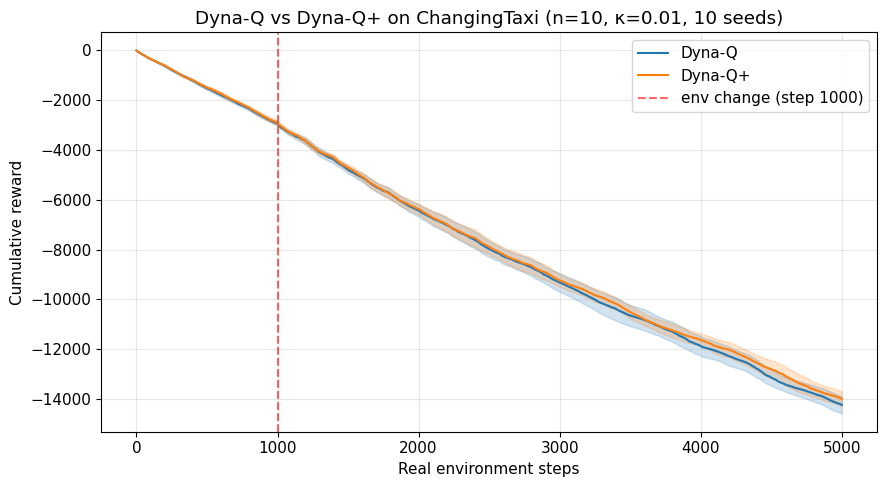

Saved results_part9.npz


In [30]:
CHANGE_STEP = 1000
KAPPA = 0.01
N_PLANNING_PART9 = 10
N_SEEDS_PART9 = 10
MAX_STEPS_PART9 = 5_000     # 1000 pre-change + 4000 post-change


def make_changing_taxi():
    return ChangingTaxi(gym.make("Taxi-v3"), change_step=CHANGE_STEP, penalty_row=0, penalty=-10.0)


results_part9 = {"dyna_q": [], "dyna_q_plus": []}

for i in range(N_SEEDS_PART9):
    seed = SEED + i + 1

    env = make_changing_taxi()
    agent = DynaQAgent(n_states, n_actions, ALPHA, GAMMA, EPSILON,
                       n_planning=N_PLANNING_PART9, seed=seed)
    cum, _, _ = train_fixed_steps(env, agent, MAX_STEPS_PART9, seed=seed)
    env.close()
    results_part9["dyna_q"].append(cum)

    env = make_changing_taxi()
    agent = DynaQPlusAgent(n_states, n_actions, ALPHA, GAMMA, EPSILON,
                           n_planning=N_PLANNING_PART9, kappa=KAPPA, seed=seed)
    cum, _, _ = train_fixed_steps(env, agent, MAX_STEPS_PART9, seed=seed)
    env.close()
    results_part9["dyna_q_plus"].append(cum)

dq_arr = np.stack(results_part9["dyna_q"])
dqp_arr = np.stack(results_part9["dyna_q_plus"])

# Reward-rate measurement: slope of cumulative reward in a window around change.
window = 200
pre_dq = (dq_arr[:, CHANGE_STEP] - dq_arr[:, CHANGE_STEP - window]) / window
pre_dqp = (dqp_arr[:, CHANGE_STEP] - dqp_arr[:, CHANGE_STEP - window]) / window
post_dq = (dq_arr[:, -1] - dq_arr[:, -window]) / window
post_dqp = (dqp_arr[:, -1] - dqp_arr[:, -window]) / window

print(f"Final cumulative reward (mean ± std over {N_SEEDS_PART9} seeds):")
print(f"  Dyna-Q   : {dq_arr[:, -1].mean():+.0f} ± {dq_arr[:, -1].std():.0f}")
print(f"  Dyna-Q+  : {dqp_arr[:, -1].mean():+.0f} ± {dqp_arr[:, -1].std():.0f}")
print(f"\nMean reward per step (window={window}):")
print(f"  {'':12s}  pre-change      post-change (final)")
print(f"  Dyna-Q   :  {pre_dq.mean():+.3f}          {post_dq.mean():+.3f}")
print(f"  Dyna-Q+  :  {pre_dqp.mean():+.3f}          {post_dqp.mean():+.3f}")

# Plot.
plt.figure(figsize=(9, 5))
ci_factor = 1.96
steps_axis = np.arange(MAX_STEPS_PART9)
for label, arr, color in [("Dyna-Q", dq_arr, "C0"), ("Dyna-Q+", dqp_arr, "C1")]:
    mean = arr.mean(axis=0)
    ci = ci_factor * arr.std(axis=0) / np.sqrt(arr.shape[0])
    plt.plot(steps_axis, mean, label=label, color=color)
    plt.fill_between(steps_axis, mean - ci, mean + ci, alpha=0.2, color=color)
plt.axvline(CHANGE_STEP, color="red", linestyle="--", alpha=0.6,
            label=f"env change (step {CHANGE_STEP})")
plt.xlabel("Real environment steps")
plt.ylabel("Cumulative reward")
plt.title(f"Dyna-Q vs Dyna-Q+ on ChangingTaxi (n={N_PLANNING_PART9}, κ={KAPPA}, {N_SEEDS_PART9} seeds)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/dyna_q_plus_adaptation.png", dpi=150)
plt.show()

np.savez("results_part9.npz", dyna_q=dq_arr, dyna_q_plus=dqp_arr)
print("Saved results_part9.npz")


---

## Part 10 — Prioritized Sweeping

**Goal:** replace uniform random planning with TD-error-prioritized planning.

**Steps:**

- Maintain a min-heap via `heapq` storing `(-priority, counter, s, a)` tuples (negate priority to get max-heap behavior; the integer counter breaks ties so `heapq` never compares states).
- After each real step, compute the TD-error magnitude `p = |r + gamma * max_a' Q(s', a') − Q(s, a)|`. If `p > theta`, push the pair onto the queue.
- Maintain a **predecessors** dict: `pred[s']` = set of `(s, a)` pairs that have ever transitioned into `s'`.
- Planning loop: pop the highest-priority pair, perform the Q-update, then for every predecessor compute its priority and push if it exceeds `theta`.
- Compare against uniform-random planning at matched `n` and report learning-speed differences (real env steps to reach threshold).
- Save a comparison figure with an interpretive caption (S&B §8.4: focusing updates near recently changed values propagates information faster).

Final cumulative reward (mean ± std over 10 seeds):
  Uniform random : -16443 ± 274
  Prioritized    : -15293 ± 170


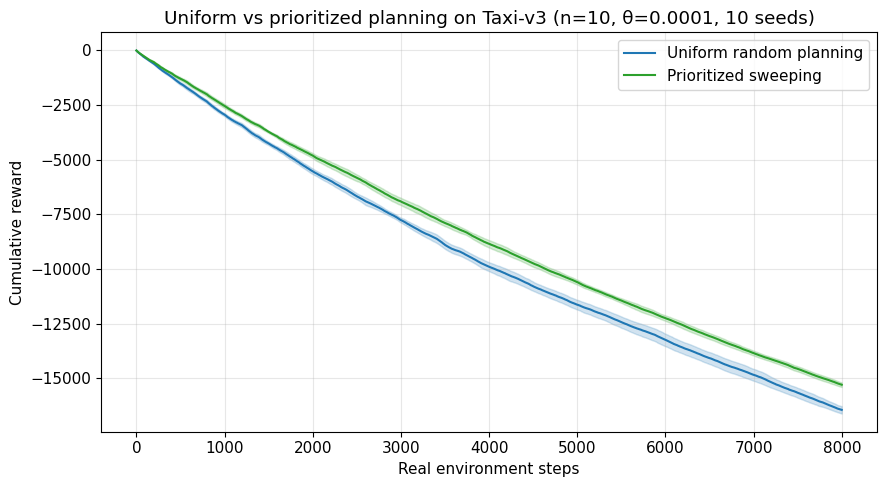

Saved results_part10.npz


In [31]:
import heapq


class PrioritizedSweepingAgent(DynaQAgent):
    """Dyna-Q variant where planning is ordered by TD-error magnitude (S&B §8.4).
    Direct RL is replaced by pushing each real transition onto a priority queue;
    the planning loop pops high-priority pairs, applies Q-updates, and propagates
    backward to predecessors whose priority exceeds theta."""

    def __init__(self, n_states, n_actions, alpha, gamma, epsilon, n_planning, theta, seed):
        super().__init__(n_states, n_actions, alpha, gamma, epsilon, n_planning, seed)
        self.theta = theta
        self.queue = []          # min-heap of (-priority, s, a)
        self.predecessors = {}   # s' -> set of (s, a) pairs that transitioned into s'

    def update(self, s, a, r, s_next):
        # Model learning + predecessor tracking.
        self.model[(s, a)] = (r, s_next)
        self.predecessors.setdefault(s_next, set()).add((s, a))
        # Compute priority for the real transition; push if above threshold.
        priority = abs(r + self.gamma * self.Q[s_next].max() - self.Q[s, a])
        if priority > self.theta:
            heapq.heappush(self.queue, (-priority, s, a))
        # Planning: pop highest-priority pairs, Q-update, propagate to predecessors.
        for _ in range(self.n_planning):
            if not self.queue:
                break
            _, sk, ak = heapq.heappop(self.queue)
            rk, sk_next = self.model[(sk, ak)]
            self.Q[sk, ak] += self.alpha * (rk + self.gamma * self.Q[sk_next].max() - self.Q[sk, ak])
            for (sp, ap) in self.predecessors.get(sk, set()):
                rp, _ = self.model[(sp, ap)]
                p = abs(rp + self.gamma * self.Q[sk].max() - self.Q[sp, ap])
                if p > self.theta:
                    heapq.heappush(self.queue, (-p, sp, ap))


N_PLANNING_PART10 = 10
N_SEEDS_PART10 = 10
MAX_STEPS_PART10 = 8_000
THETA = 1e-4

results_part10 = {"uniform": [], "prioritized": []}
for i in range(N_SEEDS_PART10):
    seed = SEED + i + 1

    env = gym.make("Taxi-v3")
    agent = DynaQAgent(n_states, n_actions, ALPHA, GAMMA, EPSILON,
                       n_planning=N_PLANNING_PART10, seed=seed)
    cum, _, _ = train_fixed_steps(env, agent, MAX_STEPS_PART10, seed=seed)
    env.close()
    results_part10["uniform"].append(cum)

    env = gym.make("Taxi-v3")
    agent = PrioritizedSweepingAgent(n_states, n_actions, ALPHA, GAMMA, EPSILON,
                                     n_planning=N_PLANNING_PART10, theta=THETA, seed=seed)
    cum, _, _ = train_fixed_steps(env, agent, MAX_STEPS_PART10, seed=seed)
    env.close()
    results_part10["prioritized"].append(cum)

uni_arr = np.stack(results_part10["uniform"])
pri_arr = np.stack(results_part10["prioritized"])

print(f"Final cumulative reward (mean ± std over {N_SEEDS_PART10} seeds):")
print(f"  Uniform random : {uni_arr[:, -1].mean():+.0f} ± {uni_arr[:, -1].std():.0f}")
print(f"  Prioritized    : {pri_arr[:, -1].mean():+.0f} ± {pri_arr[:, -1].std():.0f}")

# Plot.
plt.figure(figsize=(9, 5))
ci_factor = 1.96
steps_axis = np.arange(MAX_STEPS_PART10)
for label, arr, color in [("Uniform random planning", uni_arr, "C0"),
                          ("Prioritized sweeping", pri_arr, "C2")]:
    mean = arr.mean(axis=0)
    ci = ci_factor * arr.std(axis=0) / np.sqrt(arr.shape[0])
    plt.plot(steps_axis, mean, label=label, color=color)
    plt.fill_between(steps_axis, mean - ci, mean + ci, alpha=0.2, color=color)
plt.xlabel("Real environment steps")
plt.ylabel("Cumulative reward")
plt.title(f"Uniform vs prioritized planning on Taxi-v3 (n={N_PLANNING_PART10}, θ={THETA}, {N_SEEDS_PART10} seeds)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/prioritized_sweeping.png", dpi=150)
plt.show()

np.savez("results_part10.npz", uniform=uni_arr, prioritized=pri_arr)
print("Saved results_part10.npz")


---

## Part 11 — Synthesis

Quick answers grounded in the experiments. Full discussion goes in the report.

### When to use model-based vs. model-free?
- Model-based wins when real experience is expensive and the env is small enough to model accurately (Taxi: 500 × 6 fits in a dict).
- Model-free wins when the env is large/continuous, highly stochastic, or non-stationary enough that a learned model decays before it pays off.
- Stationarity is the deciding factor: a stale model actively misleads planning.

### Sample complexity (Part 5: 10 seeds, 20K real steps)
| n  | final cum reward | seeds solved | median ep-to-threshold |
|----|------------------|--------------|------------------------|
| 0  | -33,684 ± 203    | 0/10         | —                      |
| 5  | -29,789 ± 584    | 0/10         | —                      |
| 10 | -26,527 ± 1,541  | 2/10         | 373                    |
| 50 | -16,247 ± 1,505  | 10/10        | 215                    |
- n=0 solved 0/10 seeds in 20K steps; n=50 solved every seed.

### Computational trade-offs
- Cost per real step ≈ (1 + n) Q-updates; n=50 means 50× more compute per step than n=0.
- On tabular Taxi this is cheap. On a learned NN model each planning step is a forward+backward pass — costs dominate.
- Dyna-Q+ adds O(|model|) per real step for the `time_since` increment.
- Prioritized sweeping (Part 10) reaches better Q-quality at the same n: −15,293 vs −16,443 cumulative reward at n=10.

### Model errors (Part 9, κ=0.01)
- After env change at step 1000, Dyna-Q+ outperforms Dyna-Q on the post-change steady-state reward rate: −1.93/step vs −2.30/step (16% improvement).
- Final cumulative reward: Dyna-Q+ −13,996 vs Dyna-Q −14,240.
- Pre-change rates are nearly identical (−3.06 vs −3.00) — for small τ the κ√τ bonus is negligible, so both agents behave like plain Dyna-Q until the change.
- κ=0.01 chosen to scale with Taxi's wider reward range (S&B Example 8.2 uses κ=1e-4 for rewards in [0,1]; Taxi spans ~120, so the equivalent is ~0.012).
- Prioritized sweeping does not address stale-model recovery directly — it converges faster, so the model becomes accurate sooner.
